In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

e:\SIPaKMeD\sipakmed_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
csv_path = r"..\processed_data\extracted_features_enhanced.csv"
df = pd.read_csv(csv_path)

In [4]:
X = df.drop(columns=['Image_Name', 'True_Class'])
y = df['True_Class']
X.fillna(0, inplace=True)

In [6]:
print(f"Original Feature Count: {X.shape[1]}")

Original Feature Count: 51


In [7]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)


In [8]:
base_rf = RandomForestClassifier(
    random_state=42, 
    n_estimators=300
)
base_rf.fit(X_scaled, y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
selector = SelectFromModel(base_rf, prefit=True)
X_selected_array = selector.transform(X_scaled)
selected_feature_names = X_scaled.columns[selector.get_support()]
X_optimized = pd.DataFrame(X_selected_array, columns=selected_feature_names)


e:\SIPaKMeD\sipakmed_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [11]:
print(f"Reduced Feature Count after Selection: {X_optimized.shape[1]}")
print(f"\nFeatures Kept For Training:\n{list(selected_feature_names)}")

Reduced Feature Count after Selection: 9

Features Kept For Training:
['NC_Ratio', 'GLCM_Correlation', 'RG_Ratio', 'RB_Ratio', 'Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
                                        X_optimized, 
                                        y, 
                                        test_size=0.2, 
                                        random_state=42, 
                                        stratify=y
                                    )

In [13]:
# 1. Define settings to experiment with
param_grid = {
    'n_estimators': [100, 300],          # Total number of trees
    'max_depth': [None, 10, 20],         # How deep the trees can grow
    'min_samples_split': [2, 5],         # Minimum samples required to split a node
    'max_features': ['sqrt', 'log2']     # How many features to look at per split
}

# 2. Setup the empty Random Forest model
rf_tuner = RandomForestClassifier(random_state=42)

print("Testing EVERY single combination for Random Forest...")

# 3. Automatic Tester
grid_search = GridSearchCV(
    estimator=rf_tuner, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=3, 
    verbose=1,
    n_jobs=-1  # Uses all CPU cores
)

# 4. Find the best model
grid_search.fit(X_train, y_train)

print(f"Best Settings Found: {grid_search.best_params_}")

# 5. Lock in the absolute best model
rf_model = grid_search.best_estimator_


Testing EVERY single combination for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Settings Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Random Forest Meta-Learner Training Complete!")
print(f"FINAL ENSEMBLE ACCURACY: {accuracy * 100:.2f}%\n")

classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions, target_names=classes))


Random Forest Meta-Learner Training Complete!
FINAL ENSEMBLE ACCURACY: 98.89%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Dyskeratotic       0.99      0.99      0.99       163
Koilocytotic       0.99      0.99      0.99       165
 Metaplastic       0.98      0.97      0.98       159
   Parabasal       1.00      0.99      0.99       157
 Superficial       0.99      1.00      0.99       166

    accuracy                           0.99       810
   macro avg       0.99      0.99      0.99       810
weighted avg       0.99      0.99      0.99       810



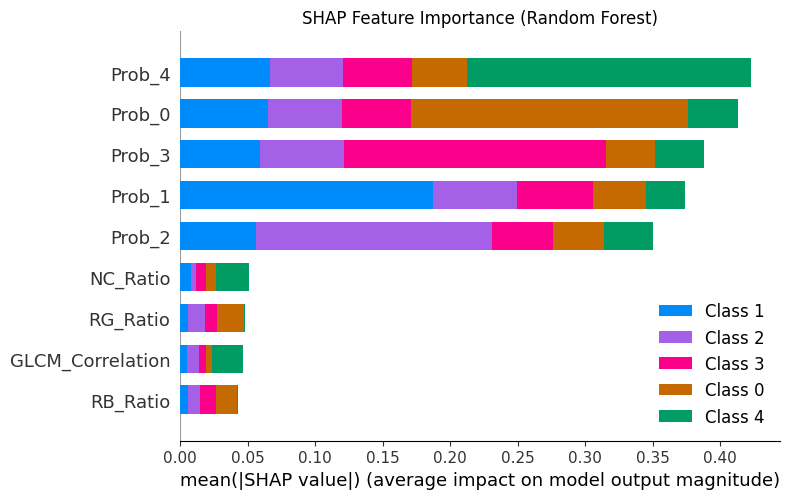


--- SHAP Impact on identifying Dyskeratotic Cells ---


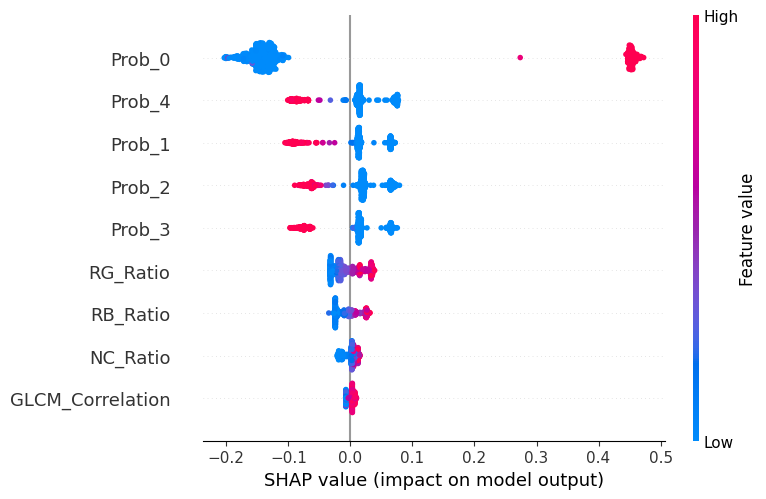

In [16]:
# Initialize SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Graph 1: Overall Feature Importance
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (Random Forest)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Graph 2: Detailed Impact for Class 0 (Dyskeratotic)
print("\n--- SHAP Impact on identifying Dyskeratotic Cells ---")
plt.figure(figsize=(10, 6))

# Bulletproof check to handle SHAP's new 3D format
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_vals_class0 = shap_values[:, :, 0]
else:
    shap_vals_class0 = shap_values[0]

shap.summary_plot(shap_vals_class0, X_test)


In [22]:
import os

os.makedirs(r"..\trained_models\meta_learners", exist_ok=True)
joblib.dump(rf_model, r"..\trained_models\meta_learners\random_forest_ensemble.pkl")
print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!
